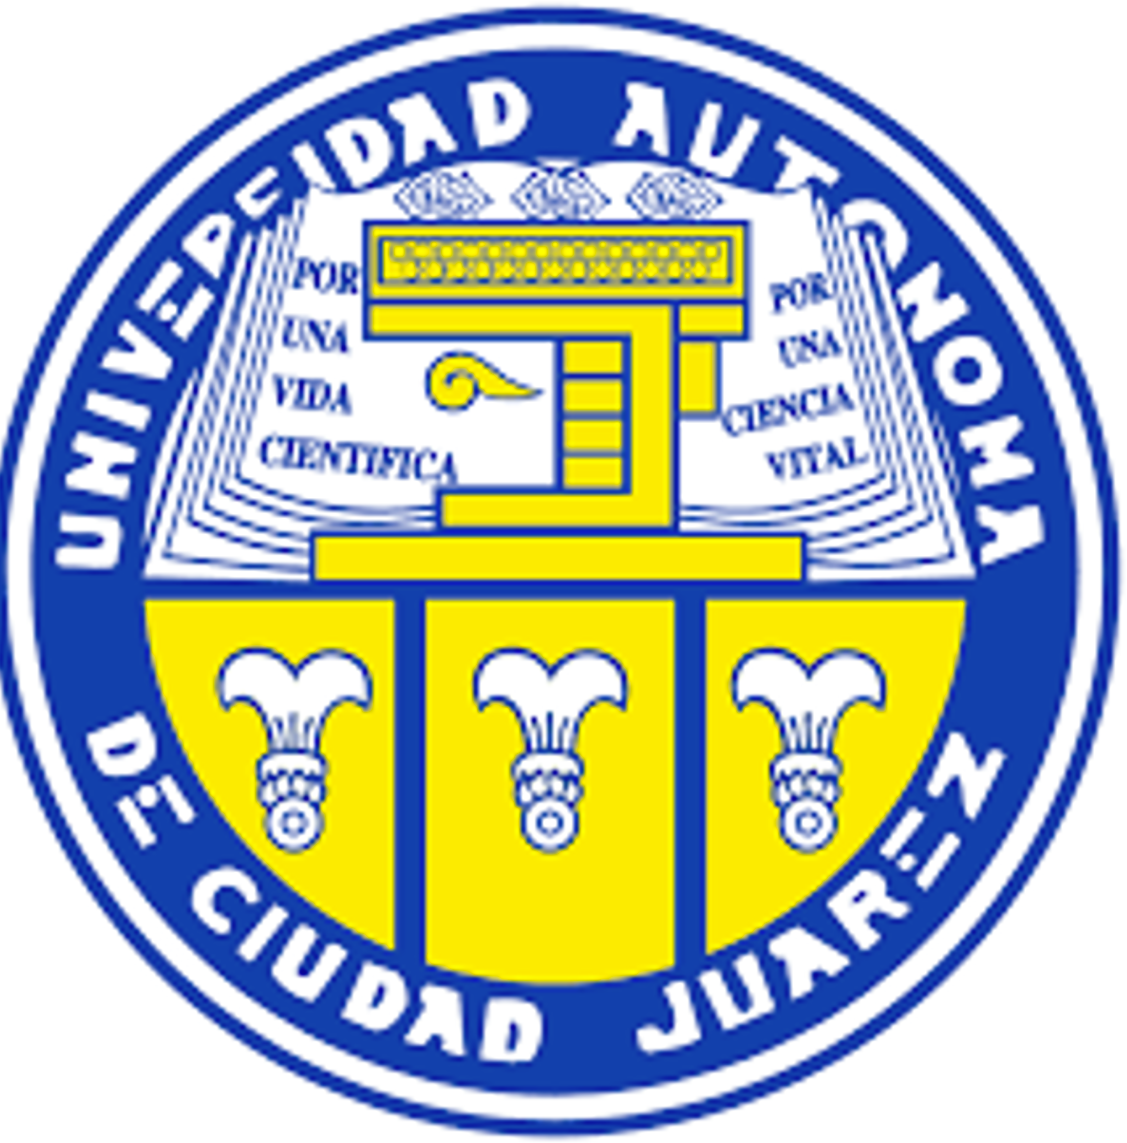

# Titulo: Tarea sobre transferencia de aprendizaje con RNN. 
# Nombre: Sergio Trejo
# Matricula: 261539
# Materia: Redes neuronales profundas_A_Presencial_26020

**Parte 1 – Reproducción del experimento base**

1. Descargar el archivo sentiment140-subset.csv y glove.6B.100d.txt   (https://nlp.stanford.edu/projects/glove/).
2. Ejecutar el código proporcionado (modelo A y modelo B).
3. Comparar los resultados de exactitud y pérdida en entrenamiento y validación.
4. Graficar las curvas accuracy y loss de ambos modelos.
5. Contestar:
    * ¿Qué diferencias observas entre el entrenamiento desde cero y el uso de embeddings preentrenados?
    * ¿Cuál converge más rápido?
    * ¿Cuál generaliza mejor (mejor desempeño en validación)?

**Parte 2: Modificación de la arquitectura.**

1. Cambiar la arquitectura:
    * Reemplazar Bidirectional(LSTM(64)) por Bidirectional(GRU(64)) y comparar. Además, agregar una capa Dropout(0.5) después de la capa recurrente Comparar resultados.
2. Evaluar con métricas adicionales:
    *  Generar y analizar una matriz de confusión.
    * Calcular precisión, recall y F1-score.
3. Prueba con nuevas oraciones:
    * Crear un bloque de código para predecir el sentimiento de frases como:

   "I really loved this trip!",

   "This was a terrible experience.",

   "My sister is afraid of going to the dentist.", etc.

In [6]:
#Librerias 
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

##  Parte 1 – Reproducción del experimento base

In [2]:
# Cargar los datos de Sentiment140

df = pd.read_csv("Dataset/sentiment140-subset.csv")  # asegúrate de descomprimirlo
texts = df["text"].astype(str).values
labels = df["polarity"].values  # 0 = negativo, 1 = positivo

# Tokenización

VOCAB_SIZE = 10000 # cantidad de palabras a considerar
MAX_LEN = 40   # máxima longitud de las oraciones
tokenizer = Tokenizer(num_words=VOCAB_SIZE, filters='!"$%&()*+,-./:;<=>?[\\]^_`{|}~\t\n')
tokenizer.fit_on_texts(texts)

X = tokenizer.texts_to_sequences(texts)
X = pad_sequences(X, maxlen=MAX_LEN, padding="post")
y = np.array(labels)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.15, random_state=42)

In [3]:
# Modelo A: Embedding entrenado desde cero
embed = 100
model_a = keras.Sequential([
    layers.Input(shape=(X.shape[1],), dtype='int32'),
    layers.Embedding(VOCAB_SIZE, embed, input_length = MAX_LEN),
    layers.Bidirectional(layers.LSTM(64)),
    layers.Dense(1, activation="sigmoid")
])
model_a.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model_a.summary()

hist_a = model_a.fit(X_train, y_train, validation_data=(X_val, y_val),
                                epochs=100, batch_size=64, verbose=2)

/home/sergioai/miniconda3/envs/ml/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 40, 100)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,084,609 (4.14 MB)

 Trainable params: 1,084,609 (4.14 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
6641/6641 - 70s - 11ms/step - accuracy: 0.7947 - loss: 0.4393 - val_accuracy: 0.8088 - val_loss: 0.4183
Epoch 2/100
6641/6641 - 68s - 10ms/step - accuracy: 0.8225 - loss: 0.3907 - val_accuracy: 0.8145 - val_loss: 0.4076
Epoch 3/100
6641/6641 - 68s - 10ms/step - accuracy: 0.8360 - loss: 0.3657 - val_accuracy: 0.8127 - val_loss: 0.4095
Epoch 4/100
6641/6641 - 68s - 10ms/step - accuracy: 0.8481 - loss: 0.3422 - val_accuracy: 0.8136 - val_loss: 0.4184
Epoch 5/100
6641/6641 - 68s - 10ms/step - accuracy: 0.8608 - loss: 0.3171 - val_accuracy: 0.8101 - val_loss: 0.4423
Epoch 6/100
6641/6641 - 69s - 10ms/step - accuracy: 0.8743 - loss: 0.2901 - val_accuracy: 0.8044 - val_loss: 0.4593
Epoch 7/100
6641/6641 - 69s - 10ms/step - accuracy: 0.8876 - loss: 0.2621 - val_accuracy: 0.8011 - val_loss: 0.4943
Epoch 8/100
6641/6641 - 70s - 10ms/step - accuracy: 0.9006 - loss: 0.2344 - val_accuracy: 0.7933 - val_loss: 0.5399
Epoch 9/100
6641/6641 - 69s - 10ms/step - accuracy: 0.9131 - loss: 0.207

In [4]:
# Modelo B: Embedding preentrenado (GloVe)

# Cargar embeddings GloVe
embeddings_index = {}

with open("Dataset/glove.6B.100d.txt", encoding="utf8") as f:
    for line in f:
        values = line.split()
        word, coefs = values[0], np.asarray(values[1:], dtype="float32")
        embeddings_index[word] = coefs

# Construir embedding matrix
embedding_matrix = np.zeros((VOCAB_SIZE, 100))
for word, i in tokenizer.word_index.items():
    if i < VOCAB_SIZE:
        vec = embeddings_index.get(word)
        if vec is not None:
            embedding_matrix[i] = vec
            
#%%
model_b = keras.Sequential([
    layers.Input(shape=(X.shape[1],), dtype='int32'),
    layers.Embedding(VOCAB_SIZE, 100, input_length=MAX_LEN,
                     weights=[embedding_matrix],
                     trainable=False),  # congelado
    layers.Bidirectional(layers.LSTM(64)),
    layers.Dense(1, activation="sigmoid")
])
model_b.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model_b.summary()

#%%
hist_b = model_b.fit(X_train, y_train, validation_data=(X_val, y_val),
                             epochs=100, batch_size=64, verbose=2)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 40, 100)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,084,609 (4.14 MB)

 Trainable params: 84,609 (330.50 KB)

 Non-trainable params: 1,000,000 (3.81 MB)

Epoch 1/100
6641/6641 - 57s - 9ms/step - accuracy: 0.7573 - loss: 0.4957 - val_accuracy: 0.7816 - val_loss: 0.4615
Epoch 2/100
6641/6641 - 56s - 8ms/step - accuracy: 0.7903 - loss: 0.4457 - val_accuracy: 0.7923 - val_loss: 0.4471
Epoch 3/100
6641/6641 - 55s - 8ms/step - accuracy: 0.8018 - loss: 0.4259 - val_accuracy: 0.7967 - val_loss: 0.4367
Epoch 4/100
6641/6641 - 55s - 8ms/step - accuracy: 0.8101 - loss: 0.4120 - val_accuracy: 0.8005 - val_loss: 0.4310
Epoch 5/100
6641/6641 - 55s - 8ms/step - accuracy: 0.8162 - loss: 0.4008 - val_accuracy: 0.8034 - val_loss: 0.4298
Epoch 6/100
6641/6641 - 55s - 8ms/step - accuracy: 0.8216 - loss: 0.3906 - val_accuracy: 0.8033 - val_loss: 0.4269
Epoch 7/100
6641/6641 - 55s - 8ms/step - accuracy: 0.8277 - loss: 0.3812 - val_accuracy: 0.8032 - val_loss: 0.4272
Epoch 8/100
6641/6641 - 56s - 8ms/step - accuracy: 0.8322 - loss: 0.3725 - val_accuracy: 0.8023 - val_loss: 0.4369
Epoch 9/100
6641/6641 - 55s - 8ms/step - accuracy: 0.8365 - loss: 0.3643 - val_a

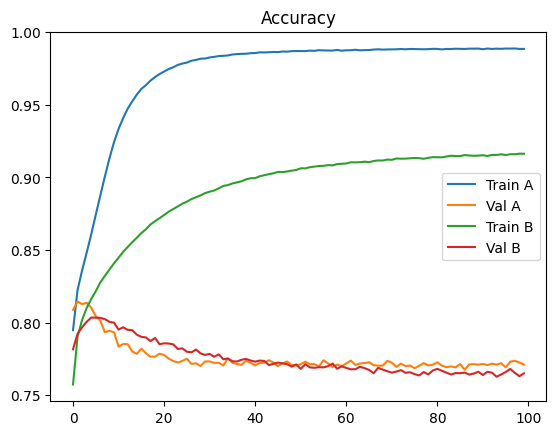

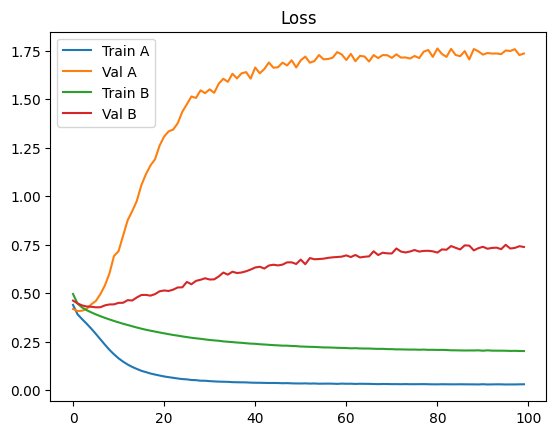

In [7]:
# Accuracy
plt.plot(hist_a.history['accuracy'], label='Train A')
plt.plot(hist_a.history['val_accuracy'], label='Val A')

plt.plot(hist_b.history['accuracy'], label='Train B')
plt.plot(hist_b.history['val_accuracy'], label='Val B')

plt.legend()
plt.title("Accuracy")
plt.show()

# Loss
plt.plot(hist_a.history['loss'], label='Train A')
plt.plot(hist_a.history['val_loss'], label='Val A')

plt.plot(hist_b.history['loss'], label='Train B')
plt.plot(hist_b.history['val_loss'], label='Val B')

plt.legend()
plt.title("Loss")
plt.show()

## Conclusiones - Parte 1
- ¿Qué diferencias observas entre el entrenamiento desde cero y el uso de embeddings preentrenados?
    * El modelo A que entrena a los embeddings desde cero tiene que aprender todo desde el inicio, no hay informacion previa del leguaje al principio. lo que toma bastante tiempo y recursos computacionales. El modelo A alcanza un accuracy muy alto en entrenamiento casi al 99%, pero solo en entrenamiento. Se sobreajusta a los datos de entrenamiento de manera muy agresiva ya que para los datos que no vio durante el proceso de validacion, los resultados de accuracy fueron muy pobres y el loss fue muy alto. Tal vez reduciendo el numero de epocas de entrenamiento podria ayudar a reducir este sobre ajuste. 

    * Por otro lado, el modelo B que ya tiene a los embeddings preentrenados inicia con conocimiento previo del lenguaje, lo que ayuda a que su aprendizaje sea mas gradual y estable. No alcanza un accuracy tan alto en entrenamiento (alrededor del 91%), pero su comportamiento es menos agresivo. Aun asi, tambien presenta sobreajuste, aunque en menor grado que el modelo A. Ajustes como reducir epocas o agregar dropout pueden ayudar a mejorar su generalizacion.

- ¿Cuál converge más rápido?
    * El modelo A converge mas rapido, ya que en pocas epocas empezo a alcanzar un accuracy muy alto en entrenamiento. Esto pasa porque todos los parametros del modelo, incluyendo el embedding, se estan ajustando al mismo tiempo. El modelo puede cambiar completamente como representa las palabras para adaptarse a los datos, por eso aprende mas rapido pero tambien se sobreajuste mas facil. 
    
    * El modelo B converge mas lento porque los embeddings ya vienen preentrenados y estan congelados, es decir, no cambian durante el entrenamiento. Esto hace que el modelo solo pueda ajustar las otras capas, por lo que el aprendizaje es mas lento pero un poco mas estable.

- ¿Cuál generaliza mejor (mejor desempeño en validación)?
    * Desde mi perspectiva, ninguno de los dos modelos generaliza muy bien, ya que ambos presentan sobreajuste fuerte. Sin embargo, sin incluir el modelo B generaliza mejor que el modelo A. Esto se observa porque mantiene un mejor desempeño en validacion y su loss o funcion de perdida crece de forma menos agresiva. En cambio, el modelo A muestra una gran diferencia entre entrenamiento y validacion, lo que indica que se aprendio los datos de entrenamiento pero no logra generalizar bien los datos nuevo que ve durante validacion.

## Parte 2: Modificación de la arquitectura.

Epoch 1/10
6641/6641 ━━━━━━━━━━━━━━━━━━━━ 79s 12ms/step - accuracy: 0.7931 - loss: 0.4439 - val_accuracy: 0.8076 - val_loss: 0.4169
Epoch 2/10
6641/6641 ━━━━━━━━━━━━━━━━━━━━ 77s 12ms/step - accuracy: 0.8214 - loss: 0.3962 - val_accuracy: 0.8128 - val_loss: 0.4078
Epoch 3/10
6641/6641 ━━━━━━━━━━━━━━━━━━━━ 78s 12ms/step - accuracy: 0.8331 - loss: 0.3738 - val_accuracy: 0.8139 - val_loss: 0.4078
Epoch 4/10
6641/6641 ━━━━━━━━━━━━━━━━━━━━ 78s 12ms/step - accuracy: 0.8442 - loss: 0.3532 - val_accuracy: 0.8128 - val_loss: 0.4117
Epoch 5/10
6641/6641 ━━━━━━━━━━━━━━━━━━━━ 78s 12ms/step - accuracy: 0.8554 - loss: 0.3321 - val_accuracy: 0.8100 - val_loss: 0.4301
Epoch 6/10
6641/6641 ━━━━━━━━━━━━━━━━━━━━ 78s 12ms/step - accuracy: 0.8666 - loss: 0.3102 - val_accuracy: 0.8062 - val_loss: 0.4400
Epoch 7/10
6641/6641 ━━━━━━━━━━━━━━━━━━━━ 78s 12ms/step - accuracy: 0.8778 - loss: 0.2875 - val_accuracy: 0.8020 - val_loss: 0.4654
Epoch 8/10
6641/6641 ━━━━━━━━━━━━━━━━━━━━ 78s 12ms/step - accuracy: 0.8876 -

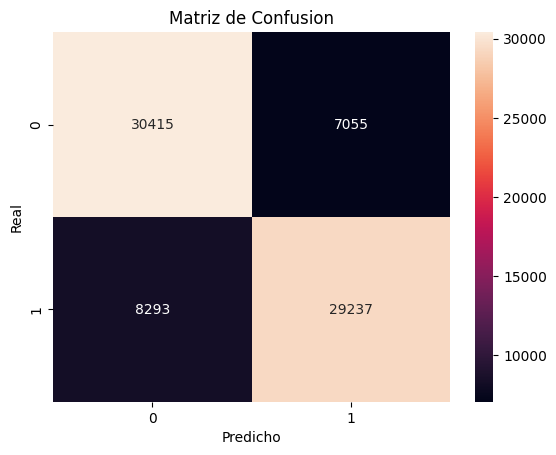

In [8]:

#Modelo C
model_c = keras.Sequential([
    layers.Input(shape=(MAX_LEN,)),
    
    layers.Embedding(VOCAB_SIZE, 100),
    
    layers.Bidirectional(layers.GRU(64)),  # cambio a GRU
    layers.Dropout(0.5),                   # nuevo
    
    layers.Dense(1, activation="sigmoid")
])

model_c.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

#Entrenamiento
hist_c = model_c.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64
)

# Predicciones en validation
y_pred = (model_c.predict(X_val) > 0.5).astype("int32")

# Importar metricas
from sklearn.metrics import confusion_matrix, classification_report

# Matriz de confusion
cm = confusion_matrix(y_val, y_pred)
print("Matriz de confusion:")
print(cm)

# Precision, Recall, F1
print("\nReporte de clasificacion:")
print(classification_report(y_val, y_pred))

#Matriz de confusion
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusion")

plt.show()

In [9]:
#Probar nuevas oraciones
def predict_sentiment(text):
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=MAX_LEN)
    pred = model_c.predict(padded)[0][0]
    
    return "Positivo" if pred > 0.5 else "Negativo"


print(predict_sentiment("I really loved this trip!"))
print(predict_sentiment("This was a terrible experience."))
print(predict_sentiment("My sister is afraid of going to the dentist."))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Positivo
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Positivo
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Positivo


## Parte 2 Conclusiones 

* En esta parte se reemplazo LSTM por GRU y se agrego una capa de dropout despues de la RNN. El modelo esta vez alcanzo en entrenamiento aproximadamente del 91%, mientras que el accuracy de validacion quedo alrededor del 80%. Para el modelo C se utilizaron 10 epocas en lugar de 100, ya que en los experimentos anteriores se observo que el modelo comienza a sobreajustarse despues de pocas epocas. Si se limitan el numero de epocas permite reducir el sobreajuste y mantener un mejor desempeño en validacion.

* Se calcularon las metricas de precision, recall y f1-score utilizando el classification_report. Los resultados muestran valores bastante equilibrados entre ambas clases, todos alrededor de 0.79–0.81, lo que indica que el modelo tiene un desempeño consistente en la clasificacion de sentimientos.

* El f1-score se mantiene alrededor de 0.79–0.80 en ambas clases, lo que confirma que existe un buen balance entre precision y recall. En general, el modelo no muestra un sesgo fuerte hacia alguna clase y presenta un comportamiento estable y balanceado en sus predicciones.

* La matriz de confusion muestra que el modelo clasifica correctamente una gran cantidad de ejemplos en ambas clases, aunque aun existen errores. Se observan falsos positivos y falsos negativos en cantidades similares, lo que indica que el modelo no esta sesgado hacia una sola clase y mantiene un comportamiento balanceado.